In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

Đang đọc dữ liệu từ: ../models/lstm_tick_4320/tensorboard/PPO_1/ ...
✅ Đã lưu biểu đồ 2x2 thành công tại: ../models/lstm_tick_4320/tensorboard/PPO_1/convergence_plot.png


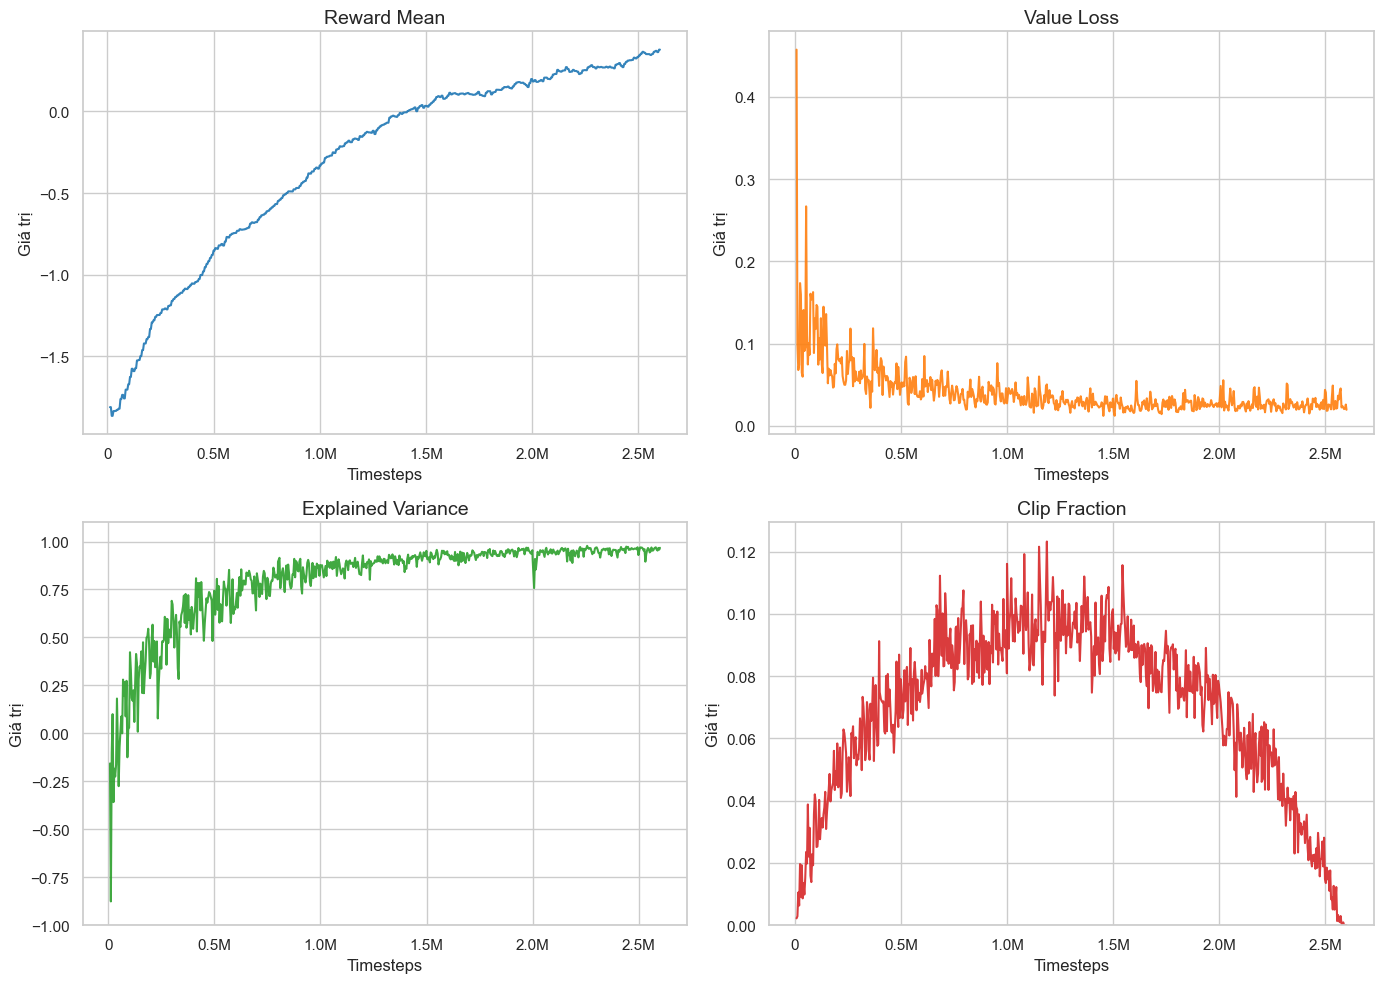

In [6]:
def extract_tb_data(log_dir: str, keys_to_extract: dict) -> dict:
    """
    Trích xuất dữ liệu gốc (raw) từ file tfevents của TensorBoard.
    """
    print(f"Đang đọc dữ liệu từ: {log_dir} ...")
    event_acc = EventAccumulator(log_dir, size_guidance={'scalars': 0})
    event_acc.Reload()

    data_dict = {}
    for key in keys_to_extract.keys():
        if key in event_acc.Tags()['scalars']:
            events = event_acc.Scalars(key)
            steps = [e.step for e in events]
            vals = [e.value for e in events]
            
            df = pd.DataFrame({'Step': steps, 'Value': vals})
            data_dict[key] = df
        else:
            print(f"Cảnh báo: Không tìm thấy key '{key}' trong file TensorBoard.")
            
    return data_dict

def plot_metrics(log_dir: str):
    # Định nghĩa đúng 4 key bạn cần
    target_keys = {
        'rollout/ep_rew_mean': 'Reward Mean',
        'train/value_loss': 'Value Loss',
        'train/explained_variance': 'Explained Variance',
        'train/clip_fraction': 'Clip Fraction'
    }

    # Lấy dữ liệu
    data = extract_tb_data(log_dir, target_keys)

    # Cài đặt giao diện
    sns.set_theme(style="whitegrid")
    
    # Tạo lưới 2x2 (2 hàng, 2 cột)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Làm phẳng mảng axes từ 2D thành 1D để dễ lặp qua
    axes = axes.flatten()
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for idx, (key, title) in enumerate(target_keys.items()):
        if key in data:
            df = data[key]
            ax = axes[idx]
            
            # Vẽ đường raw data
            ax.plot(df['Step'], df['Value'], color=colors[idx], alpha=0.9, linewidth=1.5)
            
            ax.set_title(title, fontsize=14)
            ax.set_xlabel('Timesteps', fontsize=12)
            ax.set_ylabel('Giá trị', fontsize=12)
            
            # Trục X định dạng triệu (M)
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M' if x >= 1e5 else f'{x:.0f}'))
            
            # Xử lý giới hạn trục Y cho từng biểu đồ đặc thù
            if key == 'train/explained_variance':
                ax.set_ylim(-1, 1.1)
            elif key == 'train/clip_fraction':
                ax.set_ylim(bottom=0) # Clip fraction không bao giờ âm

    plt.tight_layout()

    # Lưu ảnh vào cùng thư mục
    save_path = os.path.join(log_dir, "convergence_plot.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Đã lưu biểu đồ 2x2 thành công tại: {save_path}")
    
    plt.show()

# --- CÁCH SỬ DỤNG ---
TENSORBOARD_LOG_DIR = "../models/lstm_tick_4320/tensorboard/PPO_1/" 

plot_metrics(TENSORBOARD_LOG_DIR)